In [1]:
from IPython.display import display, Markdown

display(Markdown("# Imports"))

# Imports

In [43]:
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from pydantic import BaseModel, Field
from pydantic import Field
from typing import TypedDict, List, Literal, Optional
from langchain_core.documents import Document
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import json
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain_core.retrievers import BaseRetriever
import os
from langgraph.checkpoint.memory import InMemorySaver
from langchain_tavily import TavilySearch

load_dotenv()

True

In [3]:
from IPython.display import display, Markdown

display(Markdown("# Document splitter and Vector Store"))

# Document splitter and Vector Store

In [4]:
model_name = "sentence-transformers/all-mpnet-base-v2"
embeddings = HuggingFaceEmbeddings(model_name=model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# data={}
# with open('../data/articles.json','r') as f:
#     data=json.load(f)

In [6]:
# documents=[]
# for key,value in zip(data.keys(),data.values()):
#     documents.append(Document(metadata={"Article":key},page_content=f"{key} \n: {value}"))

In [7]:
# vector_store=FAISS.from_documents(documents,embedding=embeddings)

In [8]:
# vector_store.save_local("../data/constitution.faiss")

In [9]:
vector_store = FAISS.load_local(
    "../data/constitution_and_ipc.faiss",
    embeddings=embeddings,
    allow_dangerous_deserialization=True,
)

In [10]:
# data={}
# with open('../data/penal_code_sections.json','r') as f:
#     data=json.load(f)

In [11]:
# documents=[]
# for key,value in data.items():
#     documents.append(Document(metadata={"Section":key},page_content=f"{key} \n{value}"))

In [12]:
# print(documents[0].page_content)

IPC Section 6 - Definitions in the Code to be understood subject to exceptions 
Throughout this Code every definition of an Offence, every penal provision and every illustration of every such definition or penal provision, shall be understood subject to the exceptions contained in the Chapter entitled ?General Exceptions?, though those exceptions are not repeated in such definition, penal provision, or illustration.


In [13]:
# vector_store.add_documents(documents=documents)

In [14]:
# vector_store.save_local("../data/constitution_and_ipc.faiss")

In [15]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [16]:
res = retriever.invoke("murder related law", k=3)
for i in res:
    print(i.page_content)
    print("\n\n")

IPC Section 300 - Murder 
Except in the cases hereinafter excepted, culpable homicide is murder, if the act by which the death is caused is done with the intention of causing death, or-

2ndly.-If it is done with the intention of causing such bodily injury as the offender knows to be likely to cause the death of the person to whom the harm is caused, or-

3rdly.-If it is done with the intention of causing bodily injury to any person and the bodily injury intended to be inflicted is sufficient in the ordinary course of nature to cause death, or-

4thly.-If the person committing the act knows that it is so imminently dangerous that it must, in all probability, cause death, or such bodily injury as is likely to cause death, and commits such act without any excuse for incurring the risk of causing death or such injury as aforesaid.
IPC 300 in Simple Words
According to section 300 of the Indian Penal Code, culpable homicide is considered murder if the act is done with the intention of causi

In [17]:
from IPython.display import display, Markdown

display(Markdown("# Building nodes and states"))

# Building nodes and states

In [76]:
class schema(TypedDict):
    # Not including retriever because it is inserilisable so it is giving error with inmemorystore
    # retriever:BaseRetriever
    retrieval_required: Literal["retrieval", "web_search", "None"]
    web_searched: bool
    user_query: str
    retrieved_contexts: List[str]
    relevant_contexts: List[str]
    answer_for_query: str
    generated_response: str
    is_grounded: bool
    is_supported: bool
    is_answer_useful: bool
    evidence: str
    k: Optional[int] = Field(default=3)
    max_retry_for_revise_answer: Optional[int] = Field(default=3)
    max_retry_for_rewrite_query: Optional[int] = Field(default=2)

In [67]:
class schema_for_retrieval_decider_node(BaseModel):
    retrieval_required: Literal["retrieval", "web_search", "None"] = Field(...)


parser_for_retrieval_decider_node = PydanticOutputParser(
    pydantic_object=schema_for_retrieval_decider_node
)

sys_prompt_for_retrieval_decider_node = f"You are an AI Assistant . In retriever Indian Penal Code and Consititution of India is present . User will give you some query your task is to determine whether retrieval is required or websearch is required or none of them is required  \n Output Format -{parser_for_retrieval_decider_node.get_format_instructions()}"


def retrieval_decider_node(state: schema):
    inp = [
        SystemMessage(content=sys_prompt_for_retrieval_decider_node),
        HumanMessage(content=f"User Query - {state['user_query']}"),
    ]
    res = parser_for_retrieval_decider_node.invoke(
        main_model.invoke(inp).content
    ).retrieval_required
    return {"retrieval_required": res}

In [20]:
def retrieve_node(state: schema):
    global retriever
    retrieved_contexts = retriever.invoke(state["user_query"], k=state["k"])
    return {"retrieved_contexts": [i.page_content for i in retrieved_contexts]}

In [21]:
def direct_generation_node(state: schema):
    res = main_model.invoke(state["user_query"]).content
    return {"generated_response": res}

In [22]:
class schema_for_is_relevant_node(BaseModel):
    is_relevant_context: bool


parser_for_is_relevant_node = PydanticOutputParser(
    pydantic_object=schema_for_is_relevant_node
)


def is_relevant_node(state: schema):
    contexts = state["retrieved_contexts"]
    sys_prompt = SystemMessage(
        content=f"""User will feed you a query  and a retrieved context for that query your task is to tell whether retrieved context is relevent for answering the given query or not \n Output format - {parser_for_is_relevant_node.get_format_instructions()}"""
    )
    hmn_prompt = f"Query - {state['user_query']}"
    lst = []
    for context in contexts:
        hmn_prompt_dash = hmn_prompt + f"\n Context - {context}"
        res = parser_for_is_relevant_node.invoke(
            main_model.invoke(
                [sys_prompt, HumanMessage(content=hmn_prompt_dash)]
            ).content
        )

        lst.append(res.is_relevant_context)

    return {"relevant_contexts": [contexts[i] for i in range(len(contexts)) if lst[i]]}

In [23]:
class schema_for_answer_from_context_node(BaseModel):
    response: str = Field(..., description="Response for given query")


parser_for_answer_from_context_node = PydanticOutputParser(
    pydantic_object=schema_for_answer_from_context_node
)


def answer_from_context_node(state: schema):
    contexts = state["relevant_contexts"]
    sys_prompt_for_answer_from_context_node = SystemMessage(
        content=f"""User will give you a query and context for query your work is to give answer user query based on the context provided. \n Output format - {parser_for_answer_from_context_node.get_format_instructions()}"""
    )

    context = ""
    for i in contexts:
        context += i
        context += "\n"

    hmn_prompt = HumanMessage(
        content=f"Query - {state['user_query']} \n\n Contexts - {context}"
    )
    inp = [sys_prompt_for_answer_from_context_node, hmn_prompt]

    res = parser_for_answer_from_context_node.invoke(
        main_model.invoke(inp).content
    ).response
    return {"generated_response": res}

In [24]:
class schema_for_check_answer_grounded_node(BaseModel):
    is_grounded: Literal["fully_supported", "not_fully_supported"]
    evidence: str = Field(
        ..., description="Proof that answer is not supported by given contexts"
    )


parser_for_schema_for_check_answer_grounded_node = PydanticOutputParser(
    pydantic_object=schema_for_check_answer_grounded_node
)


def check_answer_grounded_node(state: schema):
    contexts = state["relevant_contexts"]
    sys_prompt = SystemMessage(
        content=f"You are verifying whether the ANSWER is supported by the CONTEXT.\n Output format - {parser_for_schema_for_check_answer_grounded_node.get_format_instructions()}"
    )
    context = ""
    for i in contexts:
        context += i
        context += "\n"

    human_pr = HumanMessage(
        content=f"Answer - {state['generated_response']} \n Contexts - {context}"
    )

    res = parser_for_schema_for_check_answer_grounded_node.invoke(
        main_model.invoke([sys_prompt, human_pr]).content
    )

    return {"is_grounded": res.is_grounded, "evidence": res.evidence}

In [25]:
class schema_for_revise_answer_node(BaseModel):
    revised_response: str = Field(..., description="Response for given query")


parser_for_revise_answer_node = PydanticOutputParser(
    pydantic_object=schema_for_revise_answer_node
)


def revise_answer_node(state: schema):
    contexts = state["relevent_contexts"]
    context = ""
    for i in contexts:
        context += i
        context += "\n"
    generated_response = state["generated_response"]
    user_query = state["user_query"]
    evidence = state["evidence"]

    sys_prompt = SystemMessage(
        content=f"User will give you a query ,an answer for the given query, context for the given query, response generated by llm and a evidence that the response is not fully supported by the given contexts Your task is to revise the answer such that revised answer is fully suported by the given contexts\n Output  format- {parser_for_revise_answer_node.get_format_instructions()}"
    )

    human_pr = HumanMessage(
        content=f"Query - {user_query} \n\n Generated Response - {generated_response} \n\n Contexts - {x} \n\n Evidence - {evidence}"
    )

    revised_answer = parser_for_revise_answer_node.invoke(
        critic_model.invoke([sys_prompt, human_pr]).content
    )

    return {
        "generated_response": res.revised_response,
        "max_retry_for_revise_answer": state["max_retry_for_revise_answer"] - 1,
    }

In [26]:
class schema_for_is_answer_useful_node(BaseModel):
    is_useful: bool = Field(
        ..., description="Boolean response whether answer is useful or not"
    )


parser_for_is_answer_useful_node = PydanticOutputParser(
    pydantic_object=schema_for_is_answer_useful_node
)


def is_answer_useful_node(state: schema):
    user_query = state["user_query"]
    generated_response = state["generated_response"]

    sys_prompt = SystemMessage(
        content=f"User will give you a query and a response of the query generated by llm your task is to tell whether the response solves users query or not. Output format - {parser_for_is_answer_useful_node.get_format_instructions()}"
    )
    human_pr = HumanMessage(
        content=f"Query - {user_query} \n\n Generated Response - {generated_response}"
    )

    res = parser_for_is_answer_useful_node.invoke(
        judge_model.invoke([sys_prompt, human_pr]).content
    )
    return {"is_answer_useful": res.is_useful}

In [27]:
class schema_for_rewrite_query_node(BaseModel):
    updated_query: str


parser_for_rewrite_query_node = PydanticOutputParser(
    pydantic_object=schema_for_rewrite_query_node
)


def rewrite_query_node(state: schema):
    sys_prompt = SystemMessage(
        content=f"You are a assistant whose work is to modify user query. Our vector database contains documents related to indian constitution and other acts . Users query is too vague to retrieve relevent context to answer the query your task is to rewrite the query such that it is optimised for retrieving correct context. \n Output Format - {parser_for_rewrite_query_node.get_format_instructions()}"
    )
    human_pr = state["user_query"]

    res = parser_for_rewrite_query_node.invoke(
        query_rewrite_model.invoke([sys_prompt, human_pr]).content
    )
    return {
        "user_query": res.updated_query,
        "max_retry_for_rewrite_query": state["max_retry_for_rewrite_query"] - 1,
    }

In [80]:
def web_search_node(state: schema):
    x = tavily_tool.invoke(state["user_query"])
    res = []
    for r in x["results"]:
        p = f"Source - {r['url']} \n title - {r['title']} \n {r['content']}"
        res.append(p)
    return {"relevant_contexts": res, "web_searched": True}

In [28]:
from IPython.display import display, Markdown

display(Markdown("# Building Graph"))

# Building Graph

In [29]:
def retrieval_decider_condition(state: schema):
    return state["retrieval_required"]

In [30]:
def is_relevant_condition(state: schema):
    return len(state["relevant_contexts"]) > 0

In [31]:
def is_grounded_condition(state: schema):
    return state["is_grounded"] and state["max_retry_for_revise_answer"] > 0

In [32]:
def is_answer_useful_condition(state: schema):
    return state["is_answer_useful"] and state["max_retry_for_rewrite_query"] > 0

In [33]:
ck_ptr = InMemorySaver()

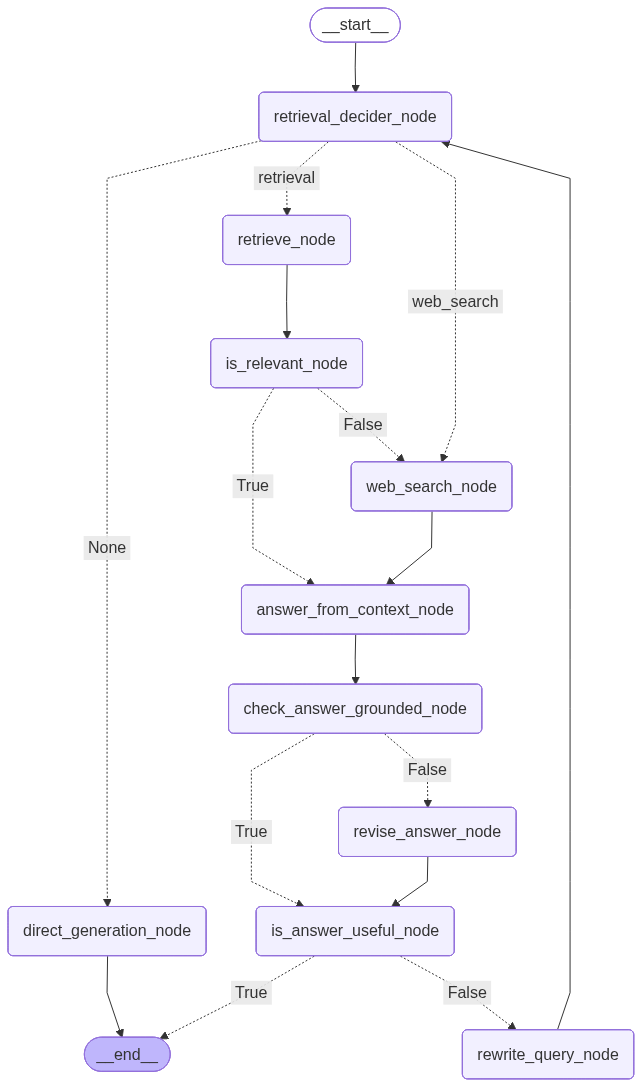

In [79]:
graph = StateGraph(state_schema=schema)

# adding nodes
# TODO - add a websearch node if none of generated contexts are relevant
graph.add_node("retrieval_decider_node", retrieval_decider_node)
graph.add_node("retrieve_node", retrieve_node)
graph.add_node("direct_generation_node", direct_generation_node)
graph.add_node("is_relevant_node", is_relevant_node)
graph.add_node("answer_from_context_node", answer_from_context_node)
graph.add_node("check_answer_grounded_node", check_answer_grounded_node)
graph.add_node("revise_answer_node", revise_answer_node)
graph.add_node("is_answer_useful_node", is_answer_useful_node)
graph.add_node("rewrite_query_node", rewrite_query_node)
graph.add_node("web_search_node", web_search_node)


graph.add_edge(START, "retrieval_decider_node")
graph.add_conditional_edges(
    "retrieval_decider_node",
    retrieval_decider_condition,
    {
        "retrieval": "retrieve_node",
        "None": "direct_generation_node",
        "web_search": "web_search_node",
    },
)
graph.add_edge("direct_generation_node", END)
graph.add_edge("retrieve_node", "is_relevant_node")
graph.add_conditional_edges(
    "is_relevant_node",
    is_relevant_condition,
    {True: "answer_from_context_node", False: "web_search_node"},
)
graph.add_edge("web_search_node", "answer_from_context_node")
graph.add_edge("answer_from_context_node", "check_answer_grounded_node")
graph.add_conditional_edges(
    "check_answer_grounded_node",
    is_grounded_condition,
    {True: "is_answer_useful_node", False: "revise_answer_node"},
)
graph.add_edge("revise_answer_node", "is_answer_useful_node")
graph.add_conditional_edges(
    "is_answer_useful_node",
    is_answer_useful_condition,
    {True: END, False: "rewrite_query_node"},
)
graph.add_edge("rewrite_query_node", "retrieval_decider_node")


workflow = graph.compile(checkpointer=ck_ptr)
workflow

In [35]:
from IPython.display import display, Markdown

display(Markdown("# Adding models"))

# Adding models

In [36]:
query_rewrite_model = ChatOllama(model="gemma4:31b-cloud")
judge_model = ChatOllama(model="gemma4:31b-cloud")
critic_model = ChatOllama(model="gemma4:31b-cloud")
main_model = ChatOllama(model="gemma4:31b-cloud")

In [37]:
from IPython.display import display, Markdown

display(Markdown("# Testing workflow"))

# Testing workflow

In [58]:
initial_state = {
    # 'retriever':retriever,
    "user_query": "Updates about 2026 state elections in india?.",
    "k": 3,
    "max_retry_for_revise_answer": 3,
    "max_retry_for_rewrite_query": 2,
}

In [44]:
tavily_tool = TavilySearch(max_results=3)

In [59]:
# x=tavily_tool.invoke("what is india?")

In [60]:
# res=""
# for r in x['results']:
#     p=f"Source - {r['url']} \n title - {r['title']} \n {r['content']}\n\n"
#     res+=p
# print(res)

In [39]:
# retriever.invoke("Describe murder releated laws in detail.")

In [40]:
display(Markdown(main_model.invoke("what is this?").content))

I cannot see what you are referring to. You haven't uploaded an image or provided a description yet!

**Please do one of the following so I can help you:**

1. **Upload a photo** of the object.
2. **Paste a link** to an image or article.
3. **Describe it in detail** (What color is it? What shape is it? Where did you find it? Does it have any writing on it?).


In [74]:
response = workflow.invoke(initial_state, {"configurable": {"thread_id": "thread-4"}})

In [87]:
for chunk in workflow.stream(
    initial_state, {"configurable": {"thread_id": "thread-4"}}, stream_mode="updates"
):
    print(list(chunk.keys())[0], "is completed")

retrieval_decider_node is completed
web_search_node is completed
answer_from_context_node is completed
check_answer_grounded_node is completed
is_answer_useful_node is completed


{'thread_id': 'thread-4',
 'ls_integration': 'langchain_chat_model',
 'langgraph_step': 28,
 'langgraph_node': 'retrieval_decider_node',
 'langgraph_triggers': ('branch:to:retrieval_decider_node',),
 'langgraph_path': ('__pregel_pull', 'retrieval_decider_node'),
 'langgraph_checkpoint_ns': 'retrieval_decider_node:7f05ef01-bdeb-5c49-8629-1528c2b91f2c',
 'checkpoint_ns': 'retrieval_decider_node:7f05ef01-bdeb-5c49-8629-1528c2b91f2c',
 'ls_provider': 'ollama',
 'ls_model_name': 'gemma4:31b-cloud',
 'ls_model_type': 'chat',
 'ls_temperature': None}

In [75]:
display(Markdown(response["generated_response"]))

The 2026 state elections in India are expected to include elections for the Rajya Sabha, as well as the legislative assemblies of four states (Assam, Kerala, Tamil Nadu, and West Bengal) and one union territory (Puducherry). According to the provided context, the elections are scheduled for April 9 in Assam, Kerala, and Puducherry; April 23 in Tamil Nadu; and in two phases on April 23 and April 29 in West Bengal.

In [98]:
response

{'retrieval_required': False,
 'user_query': 'What is AI?.',
 'answer_for_query': 'At its simplest level, **Artificial Intelligence (AI)** is the ability of a computer or a robot to perform tasks that typically require human intelligence. \n\nWhile traditional computer programs follow a strict set of "if-then" rules written by a human, AI is designed to **learn from data**, recognize patterns, and make decisions to achieve a specific goal.\n\nHere is a breakdown of how it works, the different types, and where we see it today.\n\n---\n\n### 1. How does AI actually work?\nMost modern AI is based on a field called **Machine Learning (ML)**. Instead of being told exactly how to solve a problem, the AI is fed massive amounts of data. It looks for patterns in that data to build a mathematical model.\n\n*   **Example:** To teach an AI to recognize a cat, you don\'t describe a cat (pointed ears, whiskers). Instead, you show it 100,000 photos of cats. The AI identifies the common pixels and pat